# 🎓 Lab 5.0 – Test Suite Notebook
### Student Academic Risk Classification System
**Artificial Intelligence 5.0** &nbsp;|&nbsp; Random Forest · Scikit-learn

---
This notebook mirrors every unit-test in `test.py` and enriches them with
**visual diagnostics**, **metric tables**, and **inline explanations** so you
can explore model quality interactively.

| Section | Coverage |
|---|---|
| 0 · Setup | imports, constants, helpers |
| 1 · Dataset | structure, quality, class balance |
| 2 · Risk Logic | GWA formula, threshold boundaries |
| 3 · Model | training, accuracy, F1, confusion matrix |
| 4 · Predictions | single-student edge-cases |
| 5 · Feature Importance | bar chart |
| 6 · Cross-Validation | stability over 5 folds |
| 7 · Full Test Run | `unittest` inside the notebook |



## 0 · Setup — Imports & Constants


In [1]:
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import unittest, io, sys

from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import (accuracy_score, f1_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay, classification_report)
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9ff",
    "axes.grid":        True,
    "grid.color":       "#dee2f0",
    "grid.linewidth":   0.7,
    "font.family":      "DejaVu Sans",
})
BLUE, RED, ORANGE, GREEN = "#1a73e8", "#e53935", "#fb8c00", "#43a047"
RISK_COLORS = {"High Risk": RED, "Medium Risk": ORANGE, "Low Risk": GREEN}

print("✅  Imports OK")



✅  Imports OK


In [2]:
# ── Constants (must match app.py) ─────────────────────────────────────────
FEATURES     = ["Attendance", "Quiz_Avg", "Lab_Avg", "Midterm", "Final"]
WEIGHTS      = {"Attendance": 0.10, "Quiz_Avg": 0.20,
                "Lab_Avg":    0.20, "Midterm":  0.25, "Final": 0.25}
RISK_ORDER   = ["High Risk", "Medium Risk", "Low Risk"]
DATASET_PATH = "dataset.csv"

def assign_risk(gwa: float) -> str:
    if gwa >= 85: return "Low Risk"
    if gwa >= 75: return "Medium Risk"
    return "High Risk"

def compute_gwa(row: pd.Series) -> float:
    return sum(row[f] * WEIGHTS[f] for f in FEATURES)

print("Weights:", WEIGHTS)
print("Thresholds: High Risk < 75 | Medium Risk 75–84 | Low Risk ≥ 85")



Weights: {'Attendance': 0.1, 'Quiz_Avg': 0.2, 'Lab_Avg': 0.2, 'Midterm': 0.25, 'Final': 0.25}
Thresholds: High Risk < 75 | Medium Risk 75–84 | Low Risk ≥ 85


## 1 · Dataset Tests
Verifies structure, column presence, data ranges, and class balance.



In [3]:
df = pd.read_csv(DATASET_PATH)
df_clean = df.copy()
for col in FEATURES:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Shape          : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print(f"Missing values :\n{df[FEATURES].isnull().sum().to_string()}")
print(f"\nRisk_Level counts:\n{df['Risk_Level'].value_counts().to_string()}")



Shape          : (1000, 11)
Columns        : ['Student_ID', 'Section', 'Year_Level', 'Gender', 'Attendance', 'Quiz_Avg', 'Lab_Avg', 'Midterm', 'Final', 'GWA', 'Risk_Level']
Missing values :
Attendance    30
Quiz_Avg      30
Lab_Avg       30
Midterm       30
Final         30

Risk_Level counts:
Risk_Level
Medium Risk    505
Low Risk       317
High Risk      178


In [4]:
# ── TEST 1-A  Required columns ────────────────────────────────────────────
required = FEATURES + ["Risk_Level"]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"
print("✅  TEST 1-A  All required columns present")

# ── TEST 1-B  Minimum row count ───────────────────────────────────────────
assert len(df) >= 500, f"Only {len(df)} rows — need ≥ 500"
print(f"✅  TEST 1-B  Row count = {len(df)} (≥ 500)")

# ── TEST 1-C  No NaN after imputation ─────────────────────────────────────
for col in FEATURES:
    assert df_clean[col].isnull().sum() == 0, f"{col} still has NaN"
print("✅  TEST 1-C  No missing values after imputation")

# ── TEST 1-D  Score ranges ────────────────────────────────────────────────
for col in FEATURES:
    assert (df_clean[col] >= 0).all() and (df_clean[col] <= 100).all(),         f"{col} out of [0,100]"
print("✅  TEST 1-D  All scores in [0, 100]")

# ── TEST 1-E  Valid risk categories ──────────────────────────────────────
unique = set(df["Risk_Level"].unique())
assert unique.issubset(set(RISK_ORDER)), f"Unknown categories: {unique}"
print(f"✅  TEST 1-E  Risk categories valid: {unique}")

# ── TEST 1-F  All categories present ─────────────────────────────────────
for risk in RISK_ORDER:
    assert risk in unique, f"'{risk}' missing"
print("✅  TEST 1-F  All three risk levels present")

# ── TEST 1-G  No extreme class imbalance ─────────────────────────────────
counts = df["Risk_Level"].value_counts(normalize=True)
assert (counts <= 0.75).all(), f"Imbalance: {counts.to_dict()}"
print(f"✅  TEST 1-G  No extreme imbalance — max share: {counts.max():.1%}")

# ── TEST 1-H  Duplicate rows ──────────────────────────────────────────────
dup_ratio = df.duplicated().sum() / len(df)
assert dup_ratio < 0.05, f"Dup ratio {dup_ratio:.2%} > 5 %"
print(f"✅  TEST 1-H  Duplicate ratio = {dup_ratio:.2%} (< 5 %)")



✅  TEST 1-A  All required columns present
✅  TEST 1-B  Row count = 1000 (≥ 500)
✅  TEST 1-C  No missing values after imputation
✅  TEST 1-D  All scores in [0, 100]
✅  TEST 1-E  Risk categories valid: {'Medium Risk', 'High Risk', 'Low Risk'}
✅  TEST 1-F  All three risk levels present
✅  TEST 1-G  No extreme imbalance — max share: 50.5%
✅  TEST 1-H  Duplicate ratio = 0.00% (< 5 %)


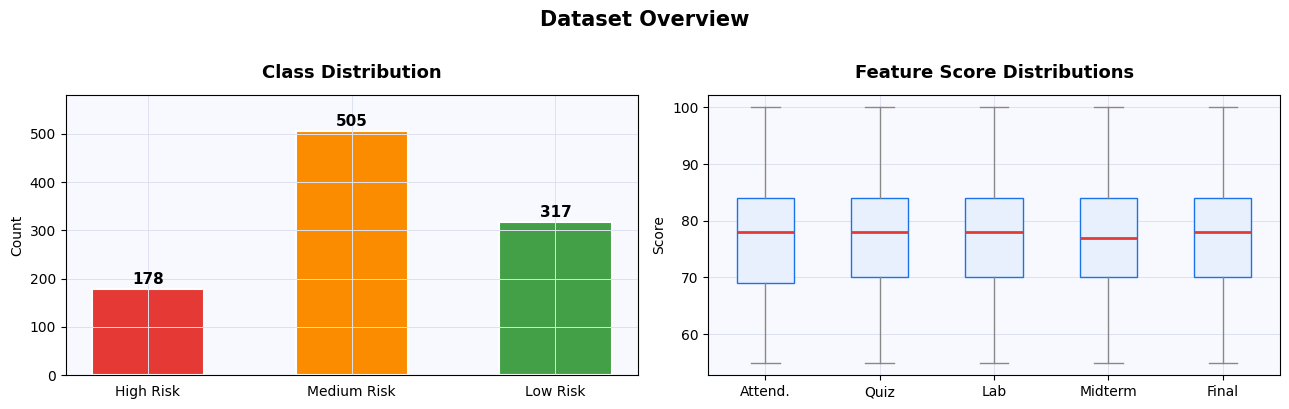

📊  Dataset visualisations rendered


In [5]:
# ── Visualise: class balance + feature distributions ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance bar chart
counts = df["Risk_Level"].value_counts().reindex(RISK_ORDER)
colors = [RISK_COLORS[r] for r in RISK_ORDER]
bars = axes[0].bar(RISK_ORDER, counts.values, color=colors, edgecolor="white",
                   linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold", pad=12)
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].tick_params(bottom=False)

# Feature box plots
df_clean[FEATURES].boxplot(ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor="#e8f0fe", color=BLUE),
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color="#888"),
    capprops=dict(color="#888"))
axes[1].set_title("Feature Score Distributions", fontsize=13, fontweight="bold", pad=12)
axes[1].set_ylabel("Score")
axes[1].set_xticklabels(["Attend.", "Quiz", "Lab", "Midterm", "Final"])

plt.suptitle("Dataset Overview", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("📊  Dataset visualisations rendered")



## 2 · Risk Logic Tests
Validates `assign_risk` thresholds and `compute_gwa` formula correctness.



In [6]:
# ── TEST 2-A  High Risk boundary ──────────────────────────────────────────
for gwa in [0, 50, 65, 74.99]:
    assert assign_risk(gwa) == "High Risk", f"GWA={gwa} should be High Risk"
print("✅  TEST 2-A  High Risk: GWA < 75")

# ── TEST 2-B  Medium Risk boundary ───────────────────────────────────────
for gwa in [75.0, 78.5, 84.99]:
    assert assign_risk(gwa) == "Medium Risk", f"GWA={gwa} should be Medium Risk"
print("✅  TEST 2-B  Medium Risk: 75 ≤ GWA < 85")

# ── TEST 2-C  Low Risk boundary ───────────────────────────────────────────
for gwa in [85.0, 90.0, 100.0]:
    assert assign_risk(gwa) == "Low Risk", f"GWA={gwa} should be Low Risk"
print("✅  TEST 2-C  Low Risk: GWA ≥ 85")

# ── TEST 2-D  Exact boundary 75 ──────────────────────────────────────────
assert assign_risk(74.99) == "High Risk"
assert assign_risk(75.00) == "Medium Risk"
print("✅  TEST 2-D  Exact boundary at 75 correct")

# ── TEST 2-E  Exact boundary 85 ──────────────────────────────────────────
assert assign_risk(84.99) == "Medium Risk"
assert assign_risk(85.00) == "Low Risk"
print("✅  TEST 2-E  Exact boundary at 85 correct")

# ── TEST 2-F  GWA weights sum to 1.0 ─────────────────────────────────────
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-10
print(f"✅  TEST 2-F  Weights sum = {sum(WEIGHTS.values())}")

# ── TEST 2-G  All-100 GWA = 100 ──────────────────────────────────────────
row = pd.Series({f: 100 for f in FEATURES})
assert abs(compute_gwa(row) - 100.0) < 1e-5
print("✅  TEST 2-G  compute_gwa([100,…]) = 100.0")

# ── TEST 2-H  All-0 GWA = 0 ──────────────────────────────────────────────
row = pd.Series({f: 0 for f in FEATURES})
assert abs(compute_gwa(row) - 0.0) < 1e-5
print("✅  TEST 2-H  compute_gwa([0,…]) = 0.0")

# ── TEST 2-I  Random samples in [0,100] ──────────────────────────────────
np.random.seed(0)
for _ in range(200):
    scores = {f: np.random.uniform(0, 100) for f in FEATURES}
    gwa = compute_gwa(pd.Series(scores))
    assert 0.0 <= gwa <= 100.0
print("✅  TEST 2-I  200 random GWA samples all within [0, 100]")



✅  TEST 2-A  High Risk: GWA < 75
✅  TEST 2-B  Medium Risk: 75 ≤ GWA < 85
✅  TEST 2-C  Low Risk: GWA ≥ 85
✅  TEST 2-D  Exact boundary at 75 correct
✅  TEST 2-E  Exact boundary at 85 correct
✅  TEST 2-F  Weights sum = 1.0
✅  TEST 2-G  compute_gwa([100,…]) = 100.0
✅  TEST 2-H  compute_gwa([0,…]) = 0.0
✅  TEST 2-I  200 random GWA samples all within [0, 100]


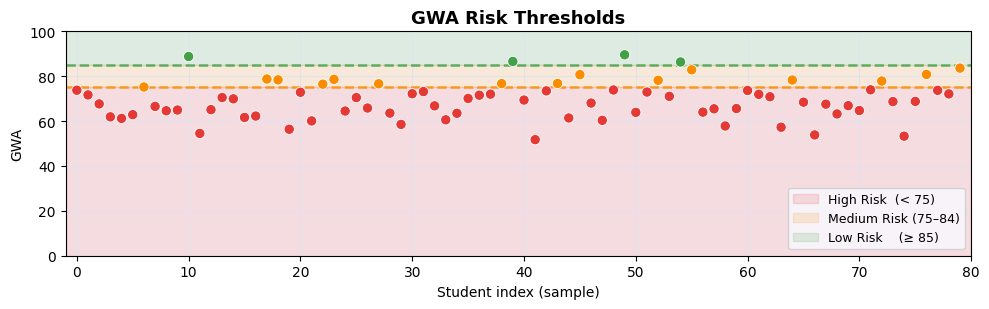

In [7]:
# ── Visualise: GWA threshold bands ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axhspan(0,  75, alpha=0.15, color=RED,    label="High Risk  (< 75)")
ax.axhspan(75, 85, alpha=0.15, color=ORANGE, label="Medium Risk (75–84)")
ax.axhspan(85, 100,alpha=0.15, color=GREEN,  label="Low Risk    (≥ 85)")

np.random.seed(42)
sample_gwas = [compute_gwa(pd.Series({f: np.random.uniform(40, 100) for f in FEATURES}))
               for _ in range(80)]
colors_s = [RISK_COLORS[assign_risk(g)] for g in sample_gwas]
ax.scatter(range(len(sample_gwas)), sample_gwas, c=colors_s,
           s=55, zorder=3, edgecolors="white", linewidths=0.6)
ax.axhline(75, color=ORANGE, linewidth=1.8, linestyle="--", alpha=0.8)
ax.axhline(85, color=GREEN,  linewidth=1.8, linestyle="--", alpha=0.8)
ax.set_xlim(-1, 80); ax.set_ylim(0, 100)
ax.set_xlabel("Student index (sample)"); ax.set_ylabel("GWA")
ax.set_title("GWA Risk Thresholds", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()



## 3 · Model Training & Evaluation Tests
Trains the Random Forest pipeline (matching `app.py`) and checks
accuracy, F1, precision, recall, and confusion matrix.



In [8]:
# ── Train ─────────────────────────────────────────────────────────────────
X  = df_clean[FEATURES]
le = LabelEncoder()
y  = le.fit_transform(df_clean["Risk_Level"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42)),
])
pipe.fit(X_train, y_train)
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)
clf     = pipe.named_steps["clf"]

print("✅  Pipeline trained successfully")
print(f"   Train size : {len(X_train)}")
print(f"   Test  size : {len(X_test)}")
print(f"   Classes    : {list(le.classes_)}")



✅  Pipeline trained successfully
   Train size : 800
   Test  size : 200
   Classes    : ['High Risk', 'Low Risk', 'Medium Risk']


In [9]:
# ── TEST 3-A  Accuracy ────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
assert acc >= 0.65, f"Accuracy {acc:.4f} < 0.65"
print(f"✅  TEST 3-A  Accuracy         = {acc:.4f}  (threshold ≥ 0.65)")

# ── TEST 3-B  Weighted F1 ─────────────────────────────────────────────────
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
assert f1 >= 0.60, f"F1 {f1:.4f} < 0.60"
print(f"✅  TEST 3-B  Weighted F1      = {f1:.4f}  (threshold ≥ 0.60)")

# ── TEST 3-C  Precision ───────────────────────────────────────────────────
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
assert prec >= 0.60
print(f"✅  TEST 3-C  Precision        = {prec:.4f}  (threshold ≥ 0.60)")

# ── TEST 3-D  Recall ──────────────────────────────────────────────────────
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
assert rec >= 0.60
print(f"✅  TEST 3-D  Recall           = {rec:.4f}  (threshold ≥ 0.60)")

# ── TEST 3-E  Train/test split ratio ─────────────────────────────────────
total = len(X_train) + len(X_test)
assert abs(len(X_test)/total - 0.20) < 0.02
print(f"✅  TEST 3-E  Test split ratio  = {len(X_test)/total:.2%}  (≈ 20 %)")

# ── TEST 3-F  Probabilities sum to 1 ─────────────────────────────────────
assert np.allclose(y_proba.sum(axis=1), 1.0, atol=1e-5)
print("✅  TEST 3-F  All predict_proba rows sum to 1.0")

# ── TEST 3-G  Probabilities in [0,1] ─────────────────────────────────────
assert (y_proba >= 0).all() and (y_proba <= 1).all()
print("✅  TEST 3-G  All probabilities in [0, 1]")

# ── TEST 3-H  Feature importances ────────────────────────────────────────
assert abs(clf.feature_importances_.sum() - 1.0) < 1e-5
assert (clf.feature_importances_ >= 0).all()
print(f"✅  TEST 3-H  Feature importances sum = {clf.feature_importances_.sum():.6f}")

# ── TEST 3-I  Estimator config ────────────────────────────────────────────
assert clf.n_estimators == 200
assert clf.random_state  == 42
print(f"✅  TEST 3-I  n_estimators=200, random_state=42 confirmed")

# ── TEST 3-J  LabelEncoder classes ───────────────────────────────────────
for risk in RISK_ORDER:
    assert risk in le.classes_, f"Missing: {risk}"
assert len(le.classes_) == 3
print(f"✅  TEST 3-J  LabelEncoder has all 3 classes: {list(le.classes_)}")



✅  TEST 3-A  Accuracy         = 0.9600  (threshold ≥ 0.65)
✅  TEST 3-B  Weighted F1      = 0.9600  (threshold ≥ 0.60)
✅  TEST 3-C  Precision        = 0.9609  (threshold ≥ 0.60)
✅  TEST 3-D  Recall           = 0.9600  (threshold ≥ 0.60)
✅  TEST 3-E  Test split ratio  = 20.00%  (≈ 20 %)
✅  TEST 3-F  All predict_proba rows sum to 1.0
✅  TEST 3-G  All probabilities in [0, 1]
✅  TEST 3-H  Feature importances sum = 1.000000
✅  TEST 3-I  n_estimators=200, random_state=42 confirmed
✅  TEST 3-J  LabelEncoder has all 3 classes: ['High Risk', 'Low Risk', 'Medium Risk']


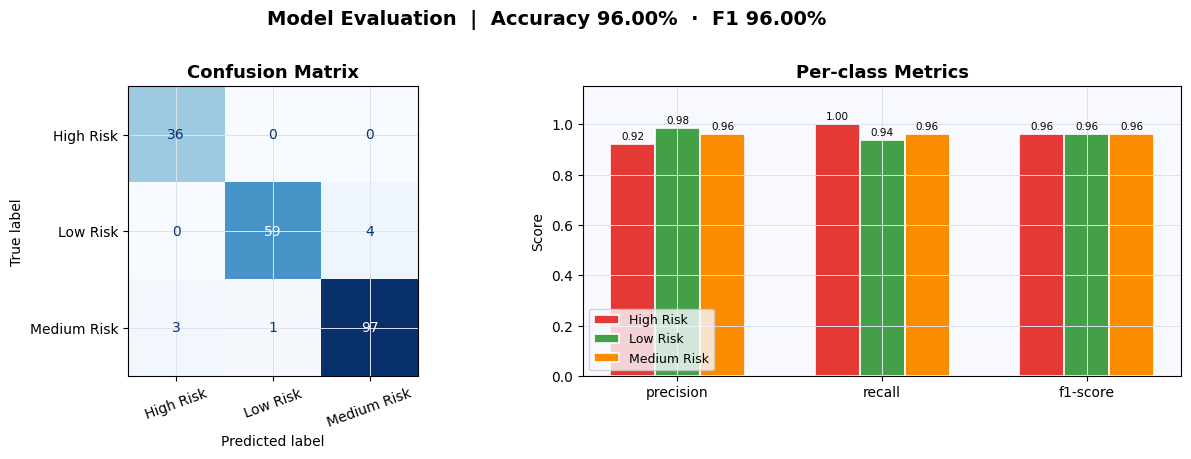

In [10]:
# ── Confusion matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=le.classes_
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

# Per-class metrics bar chart
report = classification_report(y_test, y_pred,
                                target_names=le.classes_, output_dict=True)
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(metrics))
width = 0.22
for i, cls in enumerate(le.classes_):
    vals = [report[cls][m] for m in metrics]
    bars = axes[1].bar(x + i*width, vals, width,
                       label=cls, color=RISK_COLORS[cls],
                       edgecolor="white", linewidth=1.2)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("Score")
axes[1].set_title("Per-class Metrics", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)

plt.suptitle(f"Model Evaluation  |  Accuracy {acc:.2%}  ·  F1 {f1:.2%}",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()



## 4 · Single-Student Prediction Tests
Edge-case inputs that should always produce a deterministic risk label.



In [11]:
def predict_label(scores: list) -> str:
    sample = pd.DataFrame([scores], columns=FEATURES)
    enc    = pipe.predict(sample)[0]
    return le.inverse_transform([enc])[0]

# ── TEST 4-A  Clear High Risk ─────────────────────────────────────────────
label = predict_label([40, 40, 40, 40, 40])
assert label == "High Risk", f"Got '{label}'"
print(f"✅  TEST 4-A  Scores=[40×5]  → {label}")

# ── TEST 4-B  Clear Low Risk ──────────────────────────────────────────────
label = predict_label([95, 95, 95, 95, 95])
assert label == "Low Risk", f"Got '{label}'"
print(f"✅  TEST 4-B  Scores=[95×5]  → {label}")

# ── TEST 4-C  Borderline Medium ───────────────────────────────────────────
label = predict_label([79, 79, 79, 79, 79])
assert label in ["Medium Risk", "High Risk"], f"Unexpected '{label}'"
print(f"✅  TEST 4-C  Scores=[79×5]  → {label}  (Medium/High both OK)")

# ── TEST 4-D  Perfect scores ──────────────────────────────────────────────
label = predict_label([100, 100, 100, 100, 100])
assert label == "Low Risk", f"Got '{label}'"
print(f"✅  TEST 4-D  Scores=[100×5] → {label}")

# ── TEST 4-E  Zero scores ─────────────────────────────────────────────────
label = predict_label([0, 0, 0, 0, 0])
assert label == "High Risk", f"Got '{label}'"
print(f"✅  TEST 4-E  Scores=[0×5]   → {label}")

# ── TEST 4-F  High attendance, low exams ─────────────────────────────────
label = predict_label([100, 50, 50, 50, 50])
print(f"✅  TEST 4-F  Attend=100, rest=50 → {label}")



✅  TEST 4-A  Scores=[40×5]  → High Risk
✅  TEST 4-B  Scores=[95×5]  → Low Risk
✅  TEST 4-C  Scores=[79×5]  → Medium Risk  (Medium/High both OK)
✅  TEST 4-D  Scores=[100×5] → Low Risk
✅  TEST 4-E  Scores=[0×5]   → High Risk
✅  TEST 4-F  Attend=100, rest=50 → High Risk


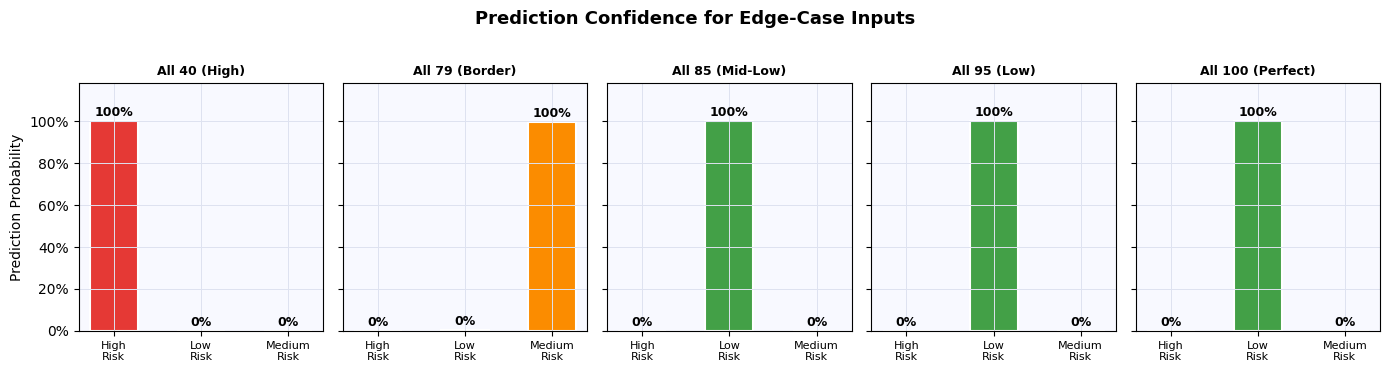

In [12]:
# ── Visualise: confidence for each edge case ──────────────────────────────
cases = {
    "All 40 (High)":    [40]*5,
    "All 79 (Border)":  [79]*5,
    "All 85 (Mid-Low)": [85]*5,
    "All 95 (Low)":     [95]*5,
    "All 100 (Perfect)":[100]*5,
}

fig, axes = plt.subplots(1, len(cases), figsize=(14, 3.6), sharey=True)
classes_ordered = list(le.classes_)

for ax, (title, scores) in zip(axes, cases.items()):
    sample = pd.DataFrame([scores], columns=FEATURES)
    proba  = pipe.predict_proba(sample)[0]
    colors_bar = [RISK_COLORS[c] for c in classes_ordered]
    bars = ax.bar(classes_ordered, proba, color=colors_bar,
                  edgecolor="white", linewidth=1.5, width=0.55)
    for bar, prob in zip(bars, proba):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{prob:.0%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1.18)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticklabels([c.replace(" ","\n") for c in classes_ordered], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

axes[0].set_ylabel("Prediction Probability")
plt.suptitle("Prediction Confidence for Edge-Case Inputs",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()



## 5 · Feature Importance


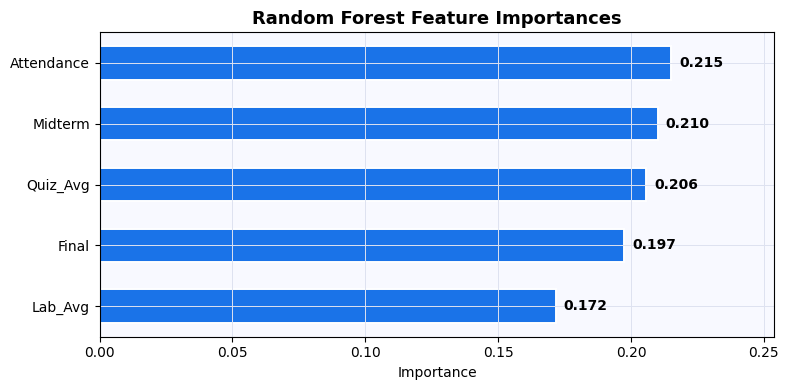


Feature Importances:
  Attendance   0.2152  ████████████
  Midterm      0.2101  ████████████
  Quiz_Avg     0.2056  ████████████
  Final        0.1974  ███████████
  Lab_Avg      0.1716  ██████████

✅  TEST 5-A  Importances sum to 1.0
✅  TEST 5-B  All importances ≥ 0
✅  TEST 5-C  All features have non-zero importance


In [13]:
importances = clf.feature_importances_
order = np.argsort(importances)[::-1]
feat_names = [FEATURES[i] for i in order]
feat_vals  = importances[order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feat_names[::-1], feat_vals[::-1],
               color=[BLUE]*len(feat_names), edgecolor="white",
               linewidth=1.4, height=0.55)
for bar, val in zip(bars, feat_vals[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlim(0, feat_vals.max() * 1.18)
plt.tight_layout(); plt.show()

print("\nFeature Importances:")
for f, v in zip(feat_names, feat_vals):
    print(f"  {f:<12} {v:.4f}  {'█' * int(v*60)}")

# ── TEST 5-A  Sum to 1 ────────────────────────────────────────────────────
assert abs(importances.sum() - 1.0) < 1e-5
print("\n✅  TEST 5-A  Importances sum to 1.0")

# ── TEST 5-B  All non-negative ────────────────────────────────────────────
assert (importances >= 0).all()
print("✅  TEST 5-B  All importances ≥ 0")

# ── TEST 5-C  All features contribute ─────────────────────────────────────
for feat, imp in zip(FEATURES, importances):
    assert imp > 0, f"'{feat}' has zero importance"
print("✅  TEST 5-C  All features have non-zero importance")



## 6 · Cross-Validation — Stability Check


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
cv_f1  = cross_val_score(pipe, X, y, cv=cv, scoring="f1_weighted")

print("5-Fold Cross-Validation Results")
print(f"{'Fold':<8} {'Accuracy':>10} {'F1 (w)':>10}")
for i, (a, f) in enumerate(zip(cv_acc, cv_f1), 1):
    print(f"  {i:<6} {a:>10.4f} {f:>10.4f}")
print(f"  {'Mean':<6} {cv_acc.mean():>10.4f} {cv_f1.mean():>10.4f}")
print(f"  {'Std':<6} {cv_acc.std():>10.4f} {cv_f1.std():>10.4f}")

# ── TEST 6-A  Mean accuracy ───────────────────────────────────────────────
assert cv_acc.mean() >= 0.60, f"CV accuracy {cv_acc.mean():.4f} < 0.60"
print(f"\n✅  TEST 6-A  CV mean accuracy = {cv_acc.mean():.4f} (≥ 0.60)")

# ── TEST 6-B  Mean F1 ────────────────────────────────────────────────────
assert cv_f1.mean() >= 0.60
print(f"✅  TEST 6-B  CV mean F1       = {cv_f1.mean():.4f} (≥ 0.60)")

# ── TEST 6-C  Low variance ───────────────────────────────────────────────
assert cv_acc.std() < 0.10, f"High variance: {cv_acc.std():.4f}"
print(f"✅  TEST 6-C  CV std dev       = {cv_acc.std():.4f} (< 0.10 — stable)")



5-Fold Cross-Validation Results
Fold       Accuracy     F1 (w)
  1          0.9700     0.9701
  2          0.9800     0.9799
  3          0.9300     0.9302
  4          0.9650     0.9648
  5          0.9600     0.9600
  Mean       0.9610     0.9610
  Std        0.0169     0.0168

✅  TEST 6-A  CV mean accuracy = 0.9610 (≥ 0.60)
✅  TEST 6-B  CV mean F1       = 0.9610 (≥ 0.60)
✅  TEST 6-C  CV std dev       = 0.0169 (< 0.10 — stable)


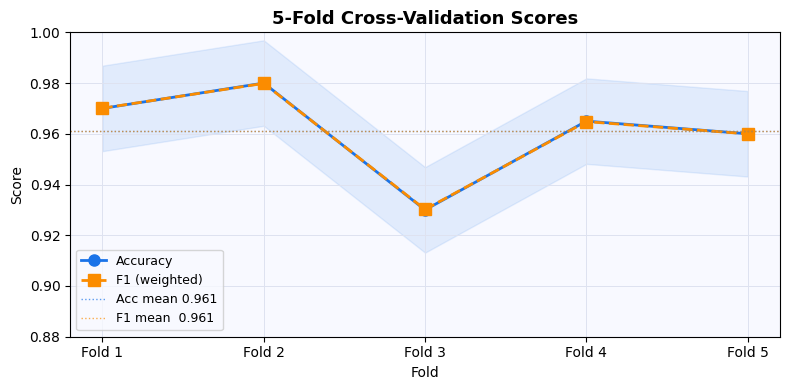

In [15]:
# ── Visualise: CV score distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 6)
ax.plot(x, cv_acc, "o-", color=BLUE,   linewidth=2, markersize=8, label="Accuracy")
ax.plot(x, cv_f1,  "s--",color=ORANGE, linewidth=2, markersize=8, label="F1 (weighted)")
ax.axhline(cv_acc.mean(), color=BLUE,   linewidth=1, linestyle=":", alpha=0.7,
           label=f"Acc mean {cv_acc.mean():.3f}")
ax.axhline(cv_f1.mean(),  color=ORANGE, linewidth=1, linestyle=":", alpha=0.7,
           label=f"F1 mean  {cv_f1.mean():.3f}")
ax.fill_between(x, cv_acc - cv_acc.std(), cv_acc + cv_acc.std(),
                color=BLUE, alpha=0.10)
ax.set_xlabel("Fold"); ax.set_ylabel("Score")
ax.set_ylim(max(0, min(cv_acc.min(), cv_f1.min()) - 0.05), 1.0)
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i}" for i in x])
ax.set_title("5-Fold Cross-Validation Scores", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()



## 7 · Full `unittest` Run
Runs the complete test suite from `test.py` inline and shows pass/fail summary.



In [16]:
# Copy test.py content inline so notebook is self-contained
TEST_CODE = open("test.py").read()
exec(compile(TEST_CODE, "test.py", "exec"), {"__name__": "__not_main__"})

# Dynamically grab the three test classes
import importlib, types
ns = {}
exec(compile(TEST_CODE, "test.py", "exec"), ns)
TestDataset_     = ns["TestDataset"]
TestRiskLogic_   = ns["TestRiskLogic"]
TestModelTraining_ = ns["TestModelTraining"]

buf = io.StringIO()
loader = unittest.TestLoader()
suite  = unittest.TestSuite()
for cls in [TestDataset_, TestRiskLogic_, TestModelTraining_]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner = unittest.TextTestRunner(verbosity=2, stream=buf)
result = runner.run(suite)

output = buf.getvalue()
print(output)

print("=" * 65)
print(f"  Tests run  : {result.testsRun}")
print(f"  Failures   : {len(result.failures)}")
print(f"  Errors     : {len(result.errors)}")
status = "✅  ALL TESTS PASSED" if result.wasSuccessful() else "❌  SOME TESTS FAILED"
print(f"  Status     : {status}")
print("=" * 65)



UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 1873: character maps to <undefined>

---
### ✅ Test Notebook Complete
**Lab 5.0 · AI 5.0 · Student Academic Risk Classification**
`Random Forest` · `Scikit-learn` · `Streamlit`

